In [150]:
import sys
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)


sns.set(style="whitegrid")

In [151]:
DATA_PATH = "../outputs"

# Archivos
df_temp_path = os.path.join(DATA_PATH, "features_temporal.parquet")
df_spa_path  = os.path.join(DATA_PATH, "features_spatial.parquet")
df_freq_path = os.path.join(DATA_PATH, "features_frequency.parquet")

df_temp = pd.read_parquet(df_temp_path)
df_spa   = pd.read_parquet(df_spa_path)
df_freq  = pd.read_parquet(df_freq_path)

# Verificar shapes
print(f"Temporal: {df_temp.shape}, Espacial: {df_spa.shape}, Frecuencia: {df_freq.shape}")


Temporal: (27850, 241), Espacial: (27850, 35), Frecuencia: (27850, 31)


Check: Todos los datasets tienen el mismo número de epochs, aunque distinto número de columnas (es correcto)

Observamos uno de los datasets

In [152]:
df_freq

,EEG_Pz_bp_delta,EEG_Pz_bp_theta,EEG_Pz_bp_alpha,EEG_Pz_bp_beta,EEG_Cz_bp_delta,EEG_Cz_bp_theta,EEG_Cz_bp_alpha,EEG_Cz_bp_beta,EEG_CPz_bp_delta,EEG_CPz_bp_theta,...,EEG_CP3_bp_theta,EEG_CP3_bp_alpha,EEG_CP3_bp_beta,EEG_CP4_bp_delta,EEG_CP4_bp_theta,EEG_CP4_bp_alpha,EEG_CP4_bp_beta,subject,epoch,label
0,0.0,0.0,1.198969,0.495786,0.0,0.0,0.460699,0.002048,0.0,0.0,...,0.0,0.124784,0.001374,0.0,0.0,0.566521,0.002262,0,0,0
1,0.0,0.0,0.812239,0.058235,0.0,0.0,0.801332,0.038162,0.0,0.0,...,0.0,0.773158,0.035492,0.0,0.0,0.313491,0.002317,0,1,0
2,0.0,0.0,1.153631,0.530731,0.0,0.0,0.090838,0.040427,0.0,0.0,...,0.0,0.171031,0.026049,0.0,0.0,0.103603,0.044774,0,2,0
3,0.0,0.0,0.956735,0.233238,0.0,0.0,0.075643,0.030842,0.0,0.0,...,0.0,0.126037,0.009303,0.0,0.0,0.338977,0.142010,0,3,0
4,0.0,0.0,2.966657,0.352383,0.0,0.0,0.129421,0.033936,0.0,0.0,...,0.0,0.625987,0.012948,0.0,0.0,0.396347,0.142472,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27845,0.0,0.0,2.216376,0.009850,0.0,0.0,2.914092,0.009249,0.0,0.0,...,0.0,1.030976,0.237886,0.0,0.0,0.322857,0.123182,49,751,0
27846,0.0,0.0,1.445273,0.014210,0.0,0.0,3.846247,0.081594,0.0,0.0,...,0.0,1.751240,0.068722,0.0,0.0,0.183115,0.042153,49,752,0
27847,0.0,0.0,0.802485,0.007845,0.0,0.0,0.706782,0.000586,0.0,0.0,...,0.0,1.296459,0.025946,0.0,0.0,0.718024,0.089672,49,753,0
27848,0.0,0.0,1.802453,0.126291,0.0,0.0,3.259989,0.018223,0.0,0.0,...,0.0,0.945969,0.007523,0.0,0.0,0.234838,0.048256,49,754,1


## Numero de sujetos

In [153]:
print("Se han analizado",len(df_freq["subject"].unique()),"sujetos.")

Se han analizado 50 sujetos.


In [154]:
def analyze_features_subject(df):
    """
    Análisis a nivel de sujeto para un único dataframe.

    - Columna 1: número de epochs por sujeto
    - Columna 2: distribución de clases por sujeto
    """

    fig, axes = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(14, 4),
        squeeze=False
    )

    # ===============================
    # 1. Número de epochs por sujeto
    # ===============================
    epochs_per_subject = df.groupby("subject").size()

    axes[0, 0].bar(
        epochs_per_subject.index.astype(str),
        epochs_per_subject.values
    )
    axes[0, 0].set_xlabel("Sujeto")
    axes[0, 0].set_ylabel("Número de epochs")
    axes[0, 0].set_title("Distribución de epochs por sujeto")

    # ==================================
    # 2. Distribución de clases por sujeto
    # ==================================
    class_per_subject = (
        df.groupby(["subject", "label"])
          .size()
          .unstack(fill_value=0)
    )

    class_per_subject.plot(
        kind="bar",
        stacked=True,
        ax=axes[0, 1],
        legend=True
    )

    axes[0, 1].set_xlabel("Sujeto")
    axes[0, 1].set_ylabel("Número de epochs")
    axes[0, 1].set_title("Distribución de clases por sujeto")

    plt.tight_layout()
    plt.show()

Distribución de clases

In [155]:
df_freq.groupby("label")["epoch"].count()

label
0    24968
1     2882
Name: epoch, dtype: int64

In [156]:
df_freq.groupby("label")["epoch"].count()[1]/df_freq.groupby("label")["epoch"].count()[0]*100

np.float64(11.542774751682153)

Distribución de epochs por archivo

In [157]:
df_freq.groupby("subject")["epoch"].count()

subject
0     540
1     540
2     720
3     720
4     720
5     540
6     720
7     720
8     718
9     719
10    720
11    700
12    716
13    360
14    720
15    720
16    720
17    720
18    329
19    486
20    316
21    474
22    220
23    289
24    104
25    429
26    692
27      1
28    584
29    136
30    631
31    181
32     29
33    512
34    306
35    458
36     29
37    693
38    633
39    756
40    756
41    756
42    756
43    734
44    754
45    749
46    756
47    756
48    756
49    756
Name: epoch, dtype: int64

Distribución de epochs por cada sujeto y clase

In [158]:
df_freq.groupby(["subject", "label"])["epoch"].count()


subject  label
0        0        480
         1         60
1        0        480
         1         60
2        0        640
                 ... 
47       1         84
48       0        672
         1         84
49       0        672
         1         84
Name: epoch, Length: 99, dtype: int64

In [159]:
df_freq.groupby("subject")["epoch"].count().min(), df_freq.groupby("subject")["epoch"].count().max()

(np.int64(1), np.int64(756))

Cada archivo edf registró entre 104 y 840 epochs.

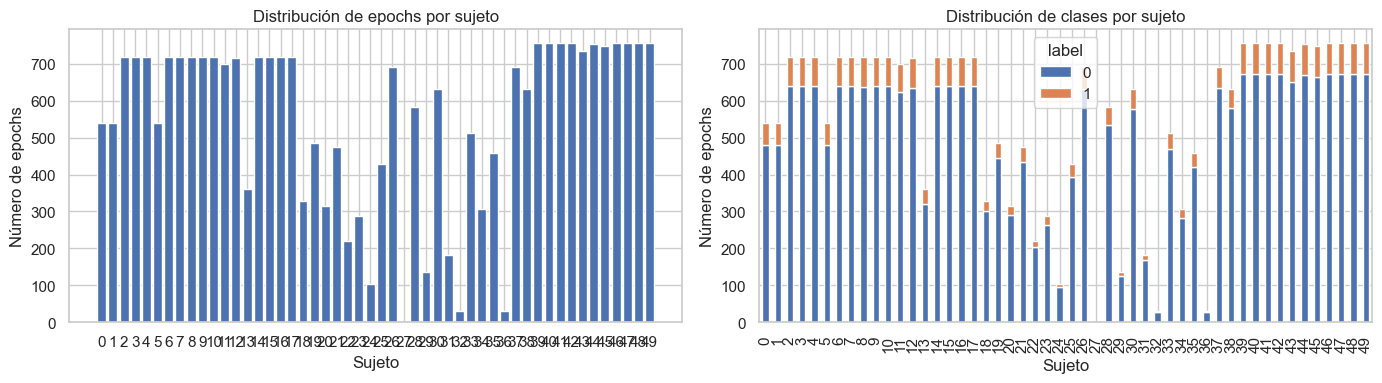

In [160]:
analyze_features_subject(df_freq)

Dependencia intra-sujeto

In [161]:
def analyze_subject_dependence(df):
    """
    Diagnóstico de dependencia intra-sujeto y riesgo de data leakage
    """

    print("\n=== Diagnóstico de estructura por sujeto ===")

    # 1. Distribución de epochs
    epochs_per_subject = df.groupby("subject").size()

    imbalance_ratio = epochs_per_subject.max() / epochs_per_subject.min()
    top_20_pct = epochs_per_subject.sort_values(ascending=False).head(
        max(1, int(0.2 * len(epochs_per_subject)))
    ).sum() / len(df)

    print(f"\nDistribución de epochs:")
    print(f"Ratio max/min: {imbalance_ratio:.2f}")
    print(f"% epochs top 20% sujetos: {top_20_pct:.2%}")

    # 2. Dependencia intra-sujeto
    numeric_features = (
        df.select_dtypes(include=np.number)
          .columns
          .drop(["label", "subject"], errors="ignore")
    )

    intra_var = (
        df.groupby("subject")[numeric_features]
          .var()
          .mean()
    )
    global_var = df[numeric_features].var()

    ratio_mean = (intra_var / global_var).mean()

    print(f"\nDependencia intra-sujeto:")
    print(f"Ratio medio var intra / global: {ratio_mean:.2f}")

    # 3. Riesgo de fuga

    train_df, val_df = train_test_split(
        df, test_size=0.2, random_state=42, stratify=df["label"]
    )

    overlap = set(train_df["subject"]).intersection(val_df["subject"])
    leakage_ratio = len(overlap) / df["subject"].nunique()

    print(f"\nRiesgo de fuga de información:")
    print(f"Sujetos compartidos train/val: {len(overlap)}")
    print(f"Proporción de fuga: {leakage_ratio:.2%}")


In [162]:
analyze_subject_dependence(df_freq)


=== Diagnóstico de estructura por sujeto ===

Distribución de epochs:
Ratio max/min: 756.00
% epochs top 20% sujetos: 27.11%

Dependencia intra-sujeto:
Ratio medio var intra / global: 0.76

Riesgo de fuga de información:
Sujetos compartidos train/val: 49
Proporción de fuga: 98.00%


In [163]:
analyze_subject_dependence(df_spa)


=== Diagnóstico de estructura por sujeto ===

Distribución de epochs:
Ratio max/min: 756.00
% epochs top 20% sujetos: 27.11%

Dependencia intra-sujeto:
Ratio medio var intra / global: 1.44

Riesgo de fuga de información:
Sujetos compartidos train/val: 49
Proporción de fuga: 98.00%


In [164]:
analyze_subject_dependence(df_temp)


=== Diagnóstico de estructura por sujeto ===

Distribución de epochs:
Ratio max/min: 756.00
% epochs top 20% sujetos: 27.11%

Dependencia intra-sujeto:
Ratio medio var intra / global: 1.29

Riesgo de fuga de información:
Sujetos compartidos train/val: 49
Proporción de fuga: 98.00%


## Información general

Todas las variables predictoras de los 3 dataset son variables numéricas. La variable objetivo es una variable binaria.

In [165]:
def outliers_detect(varaux):
    """
    Identifica valores atípicos en una serie numérica y los marca como NaN
    (solo en la serie devuelta, no modifica el dataframe original).

    Criterio:
    1) Según la forma de la distribución:
       - Distribución aproximadamente simétrica (|skew| < 1):
         se usa z-score con umbral |z| > 3
       - Distribución asimétrica:
         se usa desviación absoluta de la mediana (MAD) con umbral > 8

    2) Según rango intercuartílico ampliado:
       - Q1 = percentil 25, Q3 = percentil 75
       - H = 3 · (Q3 − Q1)
       - Valores fuera de [Q1 − H, Q3 + H]

    Un valor se considera atípico solo si cumple ambos criterios
    simultáneamente.

    Parámetros
    ----------
    varaux : pandas.Series
        Serie numérica a analizar.

    Retorna
    -------
    list:
        [serie_con_atipicos_como_NaN, numero_de_atipicos]
    """

    import numpy as np
    import statsmodels.api as sm

    varaux = varaux.copy()

    if abs(varaux.skew()) < 1:
        criterio1 = abs((varaux - varaux.mean()) / varaux.std()) > 3
    else:
        mad = sm.robust.mad(varaux, axis=0)
        criterio1 = abs((varaux - varaux.median()) / mad) > 8

    qnt = varaux.quantile([0.25, 0.75]).dropna()
    Q1 = qnt.iloc[0]
    Q3 = qnt.iloc[1]
    H = 3 * (Q3 - Q1)

    criterio2 = (varaux < (Q1 - H)) | (varaux > (Q3 + H))

    var = varaux.copy()
    mask_atipicos = criterio1 & criterio2
    var[mask_atipicos] = np.nan

    return [var, mask_atipicos.sum()]


def top_feature_correlations(df_predictors, feature_type, top_n=10, corr_threshold=0.7, plot=False):
    """
    Muestra los pares de variables predictoras con mayor correlación absoluta,
    indicando si es positiva o negativa, y opcionalmente plotea las correlaciones
    por encima de un umbral.

    Parameters
    ----------
    df_predictors : pd.DataFrame
        DataFrame con solo columnas predictoras (numéricas)
    top_n : int
        Número de pares top a mostrar
    corr_threshold : float
        Solo se muestran/plotearán pares con |correlación| >= corr_threshold
    plot : bool
        Si True, se genera un heatmap de las correlaciones filtradas

    Returns
    -------
    pd.DataFrame con columnas: ['Feature1', 'Feature2', 'Correlation']
    """
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Solo columnas numéricas
    df_num = df_predictors.select_dtypes(include=np.number)

    # Matriz de correlación
    corr_matrix = df_num.corr()

    # Tomar solo la parte superior de la matriz sin la diagonal
    corr_matrix_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    # Aplanar
    corr_pairs = corr_matrix_upper.stack().reset_index()
    corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

    # Filtrar por umbral
    corr_pairs = corr_pairs[ corr_pairs['Correlation'].abs() >= corr_threshold ]

    # Ordenar por valor absoluto de correlación
    corr_pairs['AbsCorr'] = corr_pairs['Correlation'].abs()
    corr_pairs_sorted = corr_pairs.sort_values('AbsCorr', ascending=False)

    # Seleccionar top_n
    top_corr = corr_pairs_sorted.head(top_n).copy()
    top_corr.drop(columns='AbsCorr', inplace=True)

    # Imprimir
    print(f"\nTop {len(top_corr)} pares de features con |correlación| >= {corr_threshold} para FEATURES {feature_type.upper()}:")
    for idx, row in top_corr.iterrows():
        signo = "Positiva" if row['Correlation'] > 0 else "Negativa"
        print(f"{row['Feature1']} ↔ {row['Feature2']}: {row['Correlation']:.3f} ({signo})")

    # Plot opcional
    if plot and not top_corr.empty:
        plt.figure(figsize=(8, len(top_corr)*0.4+3))
        sns.heatmap(
            corr_matrix.loc[top_corr['Feature1'], top_corr['Feature2']],
            annot=True, fmt=".2f", cmap='coolwarm', cbar=True
        )
        plt.title(f"Correlaciones > {corr_threshold}")
        plt.tight_layout()
        plt.show()

    return top_corr

def plot_cramers_v(df_predictors, target, feature_type , n_bins=10, top_n=10):
    """
    Calcula y grafica el V de Cramér entre cada feature y el target binario (0/1)
    mostrando solo las top_n features más asociadas.

    Parameters
    ----------
    df_predictors : pd.DataFrame
        DataFrame con SOLO columnas predictoras
    target : pd.Series
        Variable objetivo binaria (0/1)
    n_bins : int
        Número de bins para discretizar variables continuas
    top_n : int
        Número de features top a mostrar en el gráfico
    """
    from scipy.stats import chi2_contingency
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

    def cramers_v(x, y):
        contingency = pd.crosstab(x, y)
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            return 0.0
        chi2 = chi2_contingency(contingency)[0]
        n = contingency.sum().sum()
        r, k = contingency.shape
        return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

    cramer_values = {}
    for col in df_predictors.columns:
        x = df_predictors[col]

        if not np.issubdtype(x.dtype, np.number):
            continue

        try:
            x_binned = pd.qcut(x, q=n_bins, duplicates='drop')
            cramer_values[col] = cramers_v(x_binned, target)
        except ValueError:
            cramer_values[col] = 0.0

    cramer_df = (
        pd.DataFrame.from_dict(cramer_values, orient='index', columns=['cramers_v'])
        .sort_values('cramers_v', ascending=False)  # descendente para top
    )

    # Seleccionar solo las top_n features
    cramer_df_top = cramer_df.head(top_n)[::-1]  # invertir para barras horizontales

    # Plot
    plt.figure(figsize=(8, max(4, len(cramer_df_top) * 0.5)))
    plt.barh(cramer_df_top.index, cramer_df_top['cramers_v'], color='skyblue')
    plt.xlabel("V de Cramér")
    plt.title(f"Top {len(cramer_df_top)} features vs Target ({feature_type})")
    plt.tight_layout()
    plt.show()

    return cramer_df_top

def analyze_features(df, feature_type):
    """
    Análisis completo de features, incluyendo:
    - Missing values
    - Valores atípicos
    - Estadísticas descriptivas
    - Distribución de clases
    - Boxplots de features
    - Correlaciones entre features
    - Cramér's V con target
    - PCA 2D coloreado por labels

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame con columnas: 'subject', 'epoch', 'label', y features
    feature_type : str
        Nombre descriptivo de las features (ej. "EEG", "EMG")
    """

    print(f"\n=== Análisis de features: {feature_type} ===")

    # -----------------------------
    # Selección de columnas de features
    # -----------------------------
    feature_cols = [c for c in df.columns if c not in ['subject', 'epoch', 'label']]

    # -----------------------------
    # Análisis de valores faltantes
    # -----------------------------
    n_missing_total = df[feature_cols].isna().sum().sum()
    n_missing_per_feature = df[feature_cols].isna().sum()
    n_features_with_nans = (n_missing_per_feature > 0).sum()

    print(f"\nTotal de valores faltantes (solo features): {n_missing_total}")
    print(f"Features con al menos un NaN: {n_features_with_nans}")
    if n_features_with_nans > 0:
        print("\nNaNs por feature (features con NaNs):")
        print(n_missing_per_feature[n_missing_per_feature > 0].sort_values(ascending=False))

    # -----------------------------
    # Análisis de valores atípicos
    # -----------------------------
    print("\n=== Análisis de valores atípicos (diagnóstico) ===")
    resultados_atipicos = {}
    atipicos_por_clase = {label: 0 for label in df['label'].unique()}

    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            _, n_atipicos = outliers_detect(df[col])
            prop_atipicos = n_atipicos / len(df)
            resultados_atipicos[col] = prop_atipicos

            # Atípicos por clase
            serie_atipicos, _ = outliers_detect(df[col])
            idx_atipicos = serie_atipicos.isna()
            for label in atipicos_por_clase:
                atipicos_por_clase[label] += idx_atipicos[df['label'] == label].sum()

    # Filtrado de features con >1% atípicos
    resultados_atipicos_filtrados = {var: prop for var, prop in resultados_atipicos.items() if prop > 0.01}

    print(f"Features numéricas analizadas: {len(resultados_atipicos)}")
    print(f"Features con >1% de atípicos: {len(resultados_atipicos_filtrados)}")
    if len(resultados_atipicos_filtrados) > 0:
        print("\nProporción de atípicos por feature (>1%):")
        for var, prop in sorted(resultados_atipicos_filtrados.items(), key=lambda x: x[1], reverse=True):
            print(f"{var}: {prop:.2%}")

    print("\nResumen global de atípicos:")
    print(f"Proporción media: {np.mean(list(resultados_atipicos.values())):.2%}")
    print(f"Proporción máxima: {np.max(list(resultados_atipicos.values())):.2%}")

    # -----------------------------
    # Atípicos acumulados por clase
    # -----------------------------
    print("\n=== Atípicos acumulados por clase ===")
    total_atipicos = sum(atipicos_por_clase.values())
    for label, count in sorted(atipicos_por_clase.items(), key=lambda x: x[1], reverse=True):
        prop = count / total_atipicos if total_atipicos > 0 else 0
        print(f"Clase {label}: {count} atípicos ({prop:.2%})")

    # -----------------------------
    # Información general y estadísticas descriptivas
    # -----------------------------
    print("\nInformación general del dataframe:")
    df.info()

    print("\nEstadísticas descriptivas:")
    display(df[feature_cols].describe())

    # -----------------------------
    # Boxplots de features
    # -----------------------------
    n_plot_features = min(20, len(feature_cols))
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=df[feature_cols[:n_plot_features]])
    plt.title(f"Boxplot primeras {n_plot_features} features - {feature_type}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Correlaciones entre features
    # -----------------------------
    top_feature_correlations(df.drop(columns=['label', 'epoch', 'subject']),
                             feature_type=feature_type)

    # -----------------------------
    # Cramér's V features vs target
    # -----------------------------
    plot_cramers_v(df.drop(columns=['label', 'epoch', 'subject']),
                   df['label'], feature_type=feature_type)


    print("\n=== PCA 2D de los features ===")
    if len(feature_cols) >= 2:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(df[feature_cols])

        plt.figure(figsize=(6, 5))
        scatter = plt.scatter(
            X_pca[:, 0],
            X_pca[:, 1],
            c=df['label'].astype('category').cat.codes,
            cmap='tab20c',
            alpha=0.8,
            edgecolor='k',
            linewidth=0.3

        )

        handles, _ = scatter.legend_elements()
        labels = df['label'].astype('category').cat.categories
        plt.legend(handles, labels, title="Label")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"PCA 2D - {feature_type}")
        plt.tight_layout()
        plt.show()
    else:
        print("No hay suficientes features para PCA 2D.")

    print("\n=== Resumen final ===")
    print(f"Total filas: {len(df)}")
    print(f"Total features: {len(feature_cols)}")

import numpy as np
import matplotlib.pyplot as plt

P300_CHANNELS = [
    "EEG_Pz", "EEG_Cz", "EEG_CPz",
    "EEG_P3", "EEG_P4",
    "EEG_CP3", "EEG_CP4"
]

def plot_average_erp(df, channels=None, sf=256, title_suffix=""):
    """
    Plotea el ERP promedio target vs non-target para los canales P300.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame que contenga:
            - 'epoch_data': listas o arrays 2D (n_channels, n_times)
            - 'ch_names'   : lista con nombres de los canales
            - 'label'      : 0 (non-target) o 1 (target)
    channels : list, opcional
        Lista de canales a plotear. Default: P300_CHANNELS
    sf : int, opcional
        Frecuencia de muestreo (Hz). Default: 256
    title_suffix : str, opcional
        Texto adicional para el título del plot
    """
    if channels is None:
        channels = P300_CHANNELS

    if 'epoch_data' not in df.columns or 'ch_names' not in df.columns:
        print("ERROR: El DataFrame debe tener columnas 'epoch_data' y 'ch_names'.")
        return

    ch_names_all = df.iloc[0]['ch_names']

    for ch_idx, ch_name in enumerate(ch_names_all):
        if ch_name not in channels:
            continue

        # Extraer epochs por clase
        target_epochs = [epoch[ch_idx] for epoch, label in zip(df['epoch_data'], df['label']) if label==1]
        nontarget_epochs = [epoch[ch_idx] for epoch, label in zip(df['epoch_data'], df['label']) if label==0]

        if len(target_epochs) == 0 or len(nontarget_epochs) == 0:
            continue

        # Calcular promedio
        target_mean = np.mean(target_epochs, axis=0)
        nontarget_mean = np.mean(nontarget_epochs, axis=0)
        time = np.arange(len(target_mean)) / sf

        # Plot
        plt.figure(figsize=(8,4))
        plt.plot(time, target_mean, label='Target', color='tab:red')
        plt.plot(time, nontarget_mean, label='Non-target', color='tab:blue')
        plt.xlabel("Tiempo (s)")
        plt.ylabel("Amplitud EEG")
        plt.title(f"ERP promedio - {ch_name} {title_suffix}")
        plt.legend()
        plt.tight_layout()
        plt.show()


## Features de Frecuencia


=== Análisis de features: Frecuencia ===

Total de valores faltantes (solo features): 0
Features con al menos un NaN: 0

=== Análisis de valores atípicos (diagnóstico) ===
Features numéricas analizadas: 28
Features con >1% de atípicos: 14

Proporción de atípicos por feature (>1%):
EEG_CP3_bp_alpha: 7.95%
EEG_CP3_bp_beta: 6.24%
EEG_Cz_bp_alpha: 6.06%
EEG_CP4_bp_alpha: 5.75%
EEG_CP4_bp_beta: 5.11%
EEG_P3_bp_alpha: 4.80%
EEG_P4_bp_alpha: 4.80%
EEG_Cz_bp_beta: 4.43%
EEG_P3_bp_beta: 4.25%
EEG_CPz_bp_alpha: 3.81%
EEG_P4_bp_beta: 3.79%
EEG_Pz_bp_beta: 3.71%
EEG_CPz_bp_beta: 3.59%
EEG_Pz_bp_alpha: 3.23%

Resumen global de atípicos:
Proporción media: 2.41%
Proporción máxima: 7.95%

=== Atípicos acumulados por clase ===
Clase 0: 16979 atípicos (90.29%)
Clase 1: 1826 atípicos (9.71%)

Información general del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27850 entries, 0 to 27849
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            

,EEG_Pz_bp_delta,EEG_Pz_bp_theta,EEG_Pz_bp_alpha,EEG_Pz_bp_beta,EEG_Cz_bp_delta,EEG_Cz_bp_theta,EEG_Cz_bp_alpha,EEG_Cz_bp_beta,EEG_CPz_bp_delta,EEG_CPz_bp_theta,...,EEG_P4_bp_alpha,EEG_P4_bp_beta,EEG_CP3_bp_delta,EEG_CP3_bp_theta,EEG_CP3_bp_alpha,EEG_CP3_bp_beta,EEG_CP4_bp_delta,EEG_CP4_bp_theta,EEG_CP4_bp_alpha,EEG_CP4_bp_beta
count,27850.0,27850.0,27850.000000,27850.000000,27850.0,27850.0,27850.000000,27850.000000,27850.0,27850.0,...,27850.000000,27850.000000,27850.0,27850.0,27850.000000,27850.000000,27850.0,27850.0,27850.000000,27850.000000
mean,0.0,0.0,2.862785,0.308634,0.0,0.0,3.641418,0.263028,0.0,0.0,...,1.922596,0.185309,0.0,0.0,2.618996,0.187335,0.0,0.0,2.094086,0.223241
std,0.0,0.0,4.563211,0.518659,0.0,0.0,7.853289,0.491163,0.0,0.0,...,5.333531,0.504336,0.0,0.0,7.081625,0.467988,0.0,0.0,5.938304,0.868764
min,0.0,0.0,0.005023,0.000365,0.0,0.0,0.004233,0.000123,0.0,0.0,...,0.001518,0.000033,0.0,0.0,0.001992,0.000102,0.0,0.0,0.001119,0.000053
25%,0.0,0.0,0.589578,0.052706,0.0,0.0,0.547143,0.042534,0.0,0.0,...,0.300379,0.029128,0.0,0.0,0.287285,0.022433,0.0,0.0,0.292221,0.027309
50%,0.0,0.0,1.385299,0.136613,0.0,0.0,1.312246,0.110050,0.0,0.0,...,0.703658,0.076245,0.0,0.0,0.718859,0.061284,0.0,0.0,0.701782,0.073791
75%,0.0,0.0,3.238226,0.341378,0.0,0.0,3.394255,0.278657,0.0,0.0,...,1.657416,0.184397,0.0,0.0,1.969272,0.170937,0.0,0.0,1.743464,0.187101
max,0.0,0.0,99.233732,11.418558,0.0,0.0,302.787784,18.431614,0.0,0.0,...,173.587699,30.522748,0.0,0.0,179.403181,19.324632,0.0,0.0,270.524738,50.183261


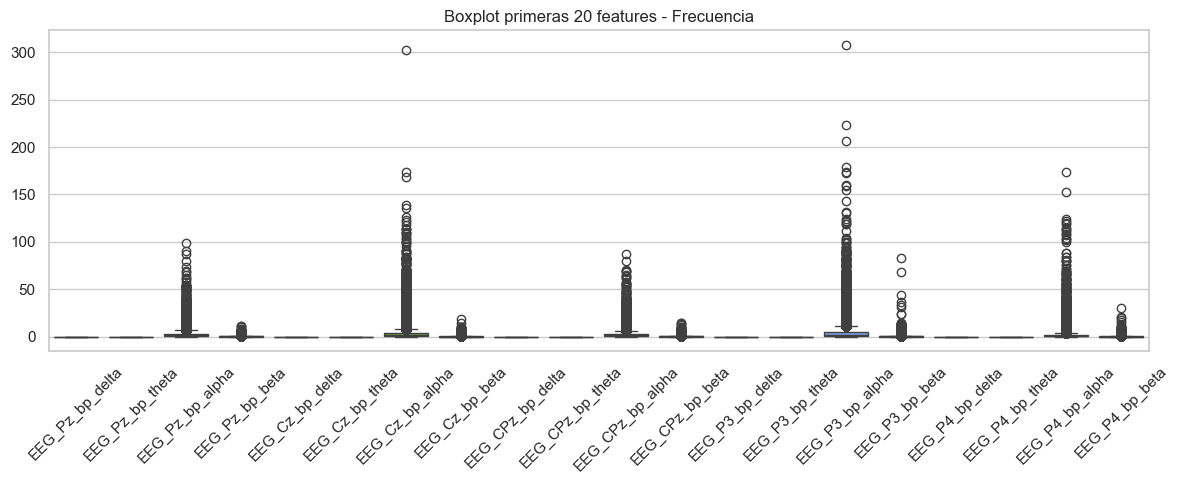


Top 2 pares de features con |correlación| >= 0.7 para FEATURES FRECUENCIA:
EEG_P4_bp_alpha ↔ EEG_CP3_bp_alpha: 0.762 (Positiva)
EEG_P4_bp_alpha ↔ EEG_CP4_bp_alpha: 0.725 (Positiva)


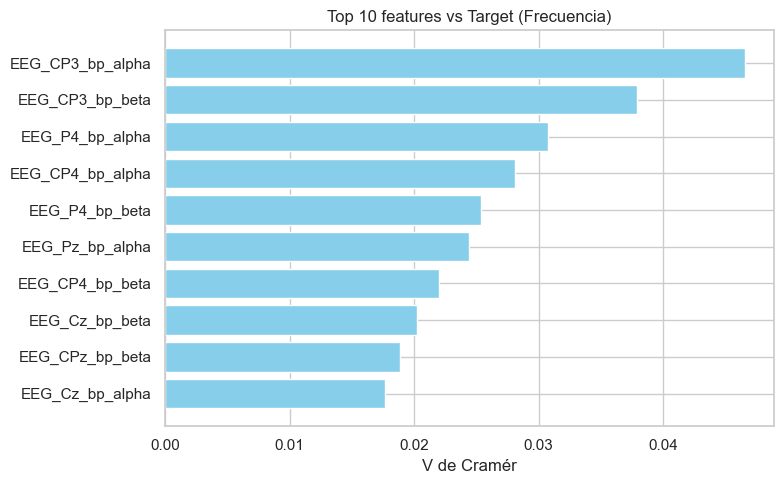


=== PCA 2D de los features ===


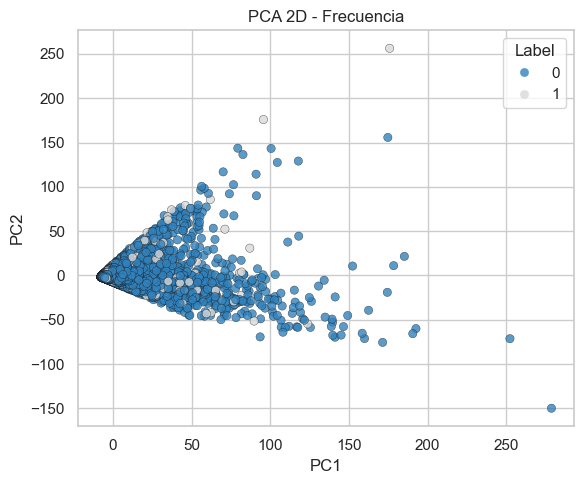


=== Resumen final ===
Total filas: 27850
Total features: 28


In [166]:
analyze_features(df_freq, "Frecuencia")

Para las features de frecuencia:

* Se observaron 1337216 valores faltantes.
* Observamos un elevado desablanceo de clases, con predominancia de la clase no objetivo.
* Observamos un elevado número de observaciones atípicas en un gran número de variables. Ninguna alcanza el 3% de atípicos.
* Observamos alta correlacion positiva entre las ondas delta de diferentes canales, superior aal 98%. Especialmente la de los canales 10, 11, 12, 13, 14 entre sí y la del canal 5 con la de los canales 10, 11, 12.  Por tanto, considerar todas estas variables implica aportar
dependencias y multicolinealidad al modelo.
* Observamos que las ondas alfa y beta del canal 5 son las que mas influyen en la variable objetivo. Le siguen los canales 15, 4 ,8 con ondas delta, alpha, delta, respectivamente.

In [167]:
plot_average_erp(df_freq)

ERROR: El DataFrame debe tener columnas 'epoch_data' y 'ch_names'.


## Features Espaciales


=== Análisis de features: Espacial ===

Total de valores faltantes (solo features): 0
Features con al menos un NaN: 0

=== Análisis de valores atípicos (diagnóstico) ===
Features numéricas analizadas: 32
Features con >1% de atípicos: 18

Proporción de atípicos por feature (>1%):
xd_comp3_min: 2.19%
xd_comp7_max: 2.14%
xd_comp3_max: 1.73%
xd_comp7_min: 1.45%
xd_comp6_auc: 1.41%
xd_comp6_mean: 1.41%
xd_comp2_mean: 1.39%
xd_comp2_auc: 1.39%
xd_comp0_mean: 1.24%
xd_comp4_mean: 1.22%
xd_comp4_auc: 1.22%
xd_comp0_auc: 1.22%
xd_comp1_auc: 1.13%
xd_comp1_mean: 1.12%
xd_comp0_min: 1.04%
xd_comp4_max: 1.02%
xd_comp7_mean: 1.01%
xd_comp7_auc: 1.01%

Resumen global de atípicos:
Proporción media: 1.01%
Proporción máxima: 2.19%

=== Atípicos acumulados por clase ===
Clase 0: 8129 atípicos (90.64%)
Clase 1: 839 atípicos (9.36%)

Información general del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27850 entries, 0 to 27849
Data columns (total 35 columns):
 #   Column         Non-Null 

,xd_comp0_mean,xd_comp0_max,xd_comp0_min,xd_comp0_auc,xd_comp1_mean,xd_comp1_max,xd_comp1_min,xd_comp1_auc,xd_comp2_mean,xd_comp2_max,...,xd_comp5_min,xd_comp5_auc,xd_comp6_mean,xd_comp6_max,xd_comp6_min,xd_comp6_auc,xd_comp7_mean,xd_comp7_max,xd_comp7_min,xd_comp7_auc
count,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,...,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000
mean,0.006643,4.554134,-4.628565,0.006705,0.004182,7.472899,-7.369089,0.004290,0.002180,7.841494,...,-7.588671,0.002215,0.001139,7.067958,-7.126415,0.000944,0.031741,7.427228,-6.993915,0.031559
std,1.973715,3.581351,3.774499,1.976957,2.505385,4.624435,4.417649,2.509166,2.840262,4.999795,...,4.567101,2.485352,2.629352,4.329091,4.516999,2.633296,3.464124,7.183407,6.158842,3.469629
min,-31.383527,0.327067,-70.735672,-31.480594,-33.942514,0.638927,-69.931013,-33.997029,-35.610905,0.587596,...,-81.613244,-40.618032,-39.177636,0.664705,-72.327548,-39.211484,-44.845721,0.415184,-100.912790,-44.834984
25%,-0.776846,2.667902,-5.471654,-0.778604,-1.233825,4.581467,-8.887410,-1.235028,-1.360880,4.717489,...,-9.169909,-1.278881,-1.165559,4.320254,-8.552233,-1.166614,-1.231045,3.656186,-7.994779,-1.233005
50%,0.020969,3.851468,-3.821217,0.020486,0.000703,6.441994,-6.403704,0.001243,-0.028809,6.668805,...,-6.599573,0.003091,0.021487,6.103652,-6.076608,0.021829,-0.023067,5.405699,-5.385576,-0.024014
75%,0.808653,5.449575,-2.635811,0.808689,1.209470,8.982468,-4.555923,1.211753,1.282564,9.358565,...,-4.707389,1.254107,1.239758,8.529900,-4.294557,1.242151,1.165678,8.174888,-3.661059,1.168261
max,44.648275,77.362286,-0.286283,44.715376,44.087345,71.245292,-0.509056,44.140050,40.867810,74.698945,...,-0.682053,44.235388,36.804376,67.453770,-0.541839,36.880814,67.394487,123.506096,-0.449290,67.486792


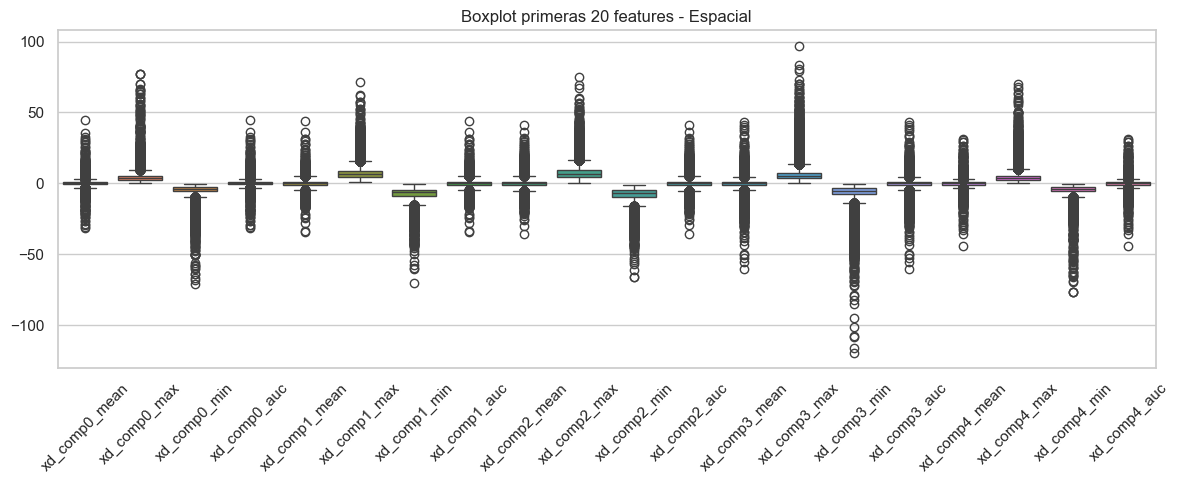


Top 10 pares de features con |correlación| >= 0.7 para FEATURES ESPACIAL:
xd_comp7_mean ↔ xd_comp7_auc: 1.000 (Positiva)
xd_comp3_mean ↔ xd_comp3_auc: 1.000 (Positiva)
xd_comp4_mean ↔ xd_comp4_auc: 1.000 (Positiva)
xd_comp0_mean ↔ xd_comp0_auc: 1.000 (Positiva)
xd_comp6_mean ↔ xd_comp6_auc: 1.000 (Positiva)
xd_comp2_mean ↔ xd_comp2_auc: 1.000 (Positiva)
xd_comp1_mean ↔ xd_comp1_auc: 1.000 (Positiva)
xd_comp5_mean ↔ xd_comp5_auc: 1.000 (Positiva)
xd_comp0_max ↔ xd_comp4_min: -0.999 (Negativa)
xd_comp0_auc ↔ xd_comp4_auc: -0.999 (Negativa)


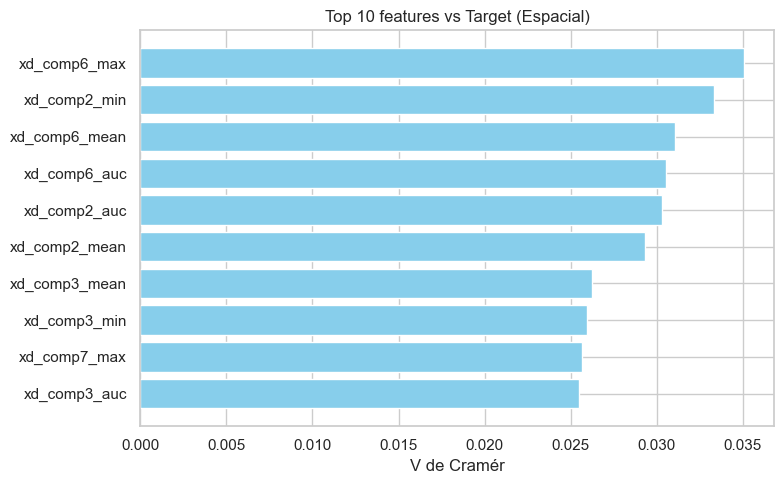


=== PCA 2D de los features ===


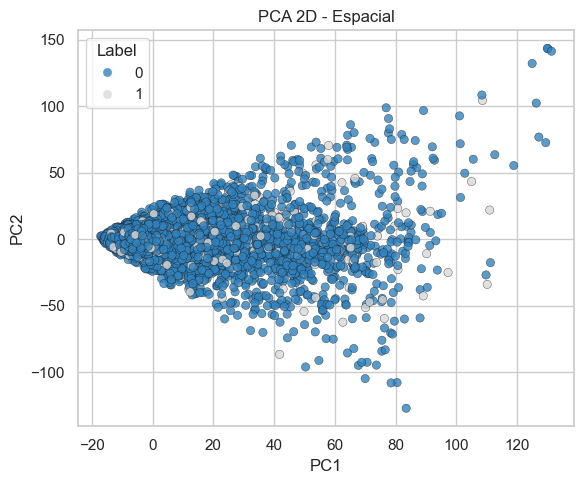


=== Resumen final ===
Total filas: 27850
Total features: 32


In [168]:
analyze_features(df_spa, "Espacial")

Para las features espaciales:

* No se observaron valores faltantes.
* Observamos un elevado desbalanceo de clases, con predominancia de la clase no objetivo.
* Observamos un elevado número de observaciones atípicas en todas las variables. Algunas alcanzado el 7% de atípicos.
* Observamos alta correlacion entre las variables, superior al 80%, pues están relacionadas matemáticamente. Por tanto, considerar todas estas variables implica aportar
dependencias y multicolinealidad al modelo.
* Observamos que el rango, la std y el mínimo son las variables con mayor influencia, en ese orden.

In [169]:
plot_average_erp(df_spa)

ERROR: El DataFrame debe tener columnas 'epoch_data' y 'ch_names'.


## Features Temporales


=== Análisis de features: Temporal ===

Total de valores faltantes (solo features): 0
Features con al menos un NaN: 0

=== Análisis de valores atípicos (diagnóstico) ===
Features numéricas analizadas: 238
Features con >1% de atípicos: 114

Proporción de atípicos por feature (>1%):
EEG_Cz_mean_6: 1.97%
EEG_Cz_auc_6: 1.94%
EEG_Pz_mean_6: 1.92%
EEG_Pz_auc_6: 1.91%
EEG_Pz_max_6: 1.84%
EEG_Cz_min_78: 1.84%
EEG_Pz_mean_78: 1.83%
EEG_Cz_mean_78: 1.83%
EEG_Pz_min_78: 1.82%
EEG_Pz_max_78: 1.79%
EEG_Cz_auc_78: 1.78%
EEG_Cz_mean_30: 1.77%
EEG_Pz_mean_30: 1.77%
EEG_Cz_mean_42: 1.76%
EEG_CP4_std: 1.76%
EEG_Pz_auc_78: 1.76%
EEG_CPz_mean_6: 1.76%
EEG_Cz_auc_30: 1.75%
EEG_Pz_mean_54: 1.75%
EEG_Cz_auc_42: 1.74%
EEG_CPz_auc_6: 1.74%
EEG_Cz_mean_54: 1.72%
EEG_Pz_auc_54: 1.71%
EEG_Cz_mean_18: 1.70%
EEG_Cz_min_30: 1.70%
EEG_CPz_max_78: 1.70%
EEG_Pz_auc_30: 1.69%
EEG_Cz_min_42: 1.69%
EEG_Pz_mean_42: 1.69%
EEG_Cz_auc_54: 1.67%
EEG_Cz_min_18: 1.66%
EEG_Pz_auc_42: 1.65%
EEG_CPz_max_6: 1.63%
EEG_Cz_auc_18: 1.6

,EEG_Pz_mean_6,EEG_Pz_max_6,EEG_Pz_min_6,EEG_Pz_auc_6,EEG_Pz_mean_18,EEG_Pz_max_18,EEG_Pz_min_18,EEG_Pz_auc_18,EEG_Pz_mean_30,EEG_Pz_max_30,...,EEG_CP4_mean_78,EEG_CP4_max_78,EEG_CP4_min_78,EEG_CP4_auc_78,EEG_CP4_std,EEG_CP4_skew,EEG_CP4_kurtosis,EEG_CP4_ptp,EEG_CP4_peak_amp,EEG_CP4_peak_lat
count,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,...,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000,27850.000000
mean,0.047168,2.587930,-2.495678,0.002047,-0.000525,2.465360,-2.467869,-0.000020,-0.072738,2.369142,...,-0.030305,1.844674,-1.907955,-0.001293,2.339425,-0.002746,-0.569403,8.974262,4.485239,0.171664
std,4.771819,5.059007,5.011631,0.206873,4.533518,4.708879,4.698143,0.197245,4.921290,5.103122,...,2.818752,3.173591,3.132878,0.123351,1.748594,0.438042,0.576865,6.607358,3.954580,0.104542
min,-55.774433,-48.890815,-62.705329,-2.420155,-47.859938,-39.033716,-52.796540,-2.067615,-54.978831,-43.920915,...,-45.998159,-43.300986,-53.586855,-1.978137,0.328224,-1.929575,-1.702574,1.396860,-36.684691,0.000000
25%,-1.940179,0.191281,-4.433858,-0.084947,-2.091745,0.095346,-4.420355,-0.091507,-2.267344,-0.157266,...,-1.277735,0.219529,-3.017816,-0.056225,1.415016,-0.281161,-0.973581,5.414953,2.420133,0.085938
50%,0.062457,2.225567,-2.102020,0.002448,-0.024965,2.070802,-2.115978,-0.000996,-0.110352,1.998585,...,-0.040155,1.475984,-1.546445,-0.001638,1.908751,-0.006189,-0.688901,7.334880,3.709626,0.175781
75%,2.086624,4.568676,-0.067040,0.091134,2.040040,4.363194,-0.144195,0.089543,2.068453,4.462435,...,1.209254,2.944070,-0.308887,0.053046,2.636370,0.274802,-0.288098,10.133149,5.415433,0.256836
max,54.378718,61.440030,51.651119,2.368870,57.942101,60.021508,54.638080,2.501764,57.048565,63.502614,...,49.736753,59.545957,41.367678,2.148224,36.292387,1.778876,5.565586,113.174723,75.170403,0.343750


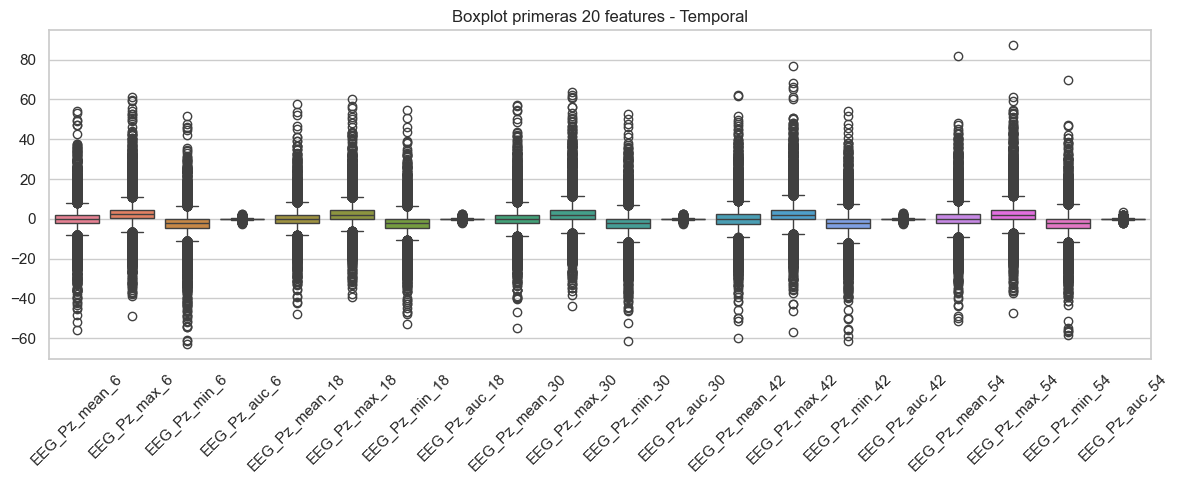


Top 10 pares de features con |correlación| >= 0.7 para FEATURES TEMPORAL:
EEG_Cz_mean_42 ↔ EEG_Cz_auc_42: 1.000 (Positiva)
EEG_Cz_mean_54 ↔ EEG_Cz_auc_54: 1.000 (Positiva)
EEG_Pz_mean_42 ↔ EEG_Pz_auc_42: 1.000 (Positiva)
EEG_Pz_mean_54 ↔ EEG_Pz_auc_54: 1.000 (Positiva)
EEG_CPz_mean_42 ↔ EEG_CPz_auc_42: 1.000 (Positiva)
EEG_Cz_mean_30 ↔ EEG_Cz_auc_30: 1.000 (Positiva)
EEG_CPz_mean_54 ↔ EEG_CPz_auc_54: 1.000 (Positiva)
EEG_Pz_mean_30 ↔ EEG_Pz_auc_30: 1.000 (Positiva)
EEG_Cz_mean_66 ↔ EEG_Cz_auc_66: 1.000 (Positiva)
EEG_Cz_mean_18 ↔ EEG_Cz_auc_18: 1.000 (Positiva)


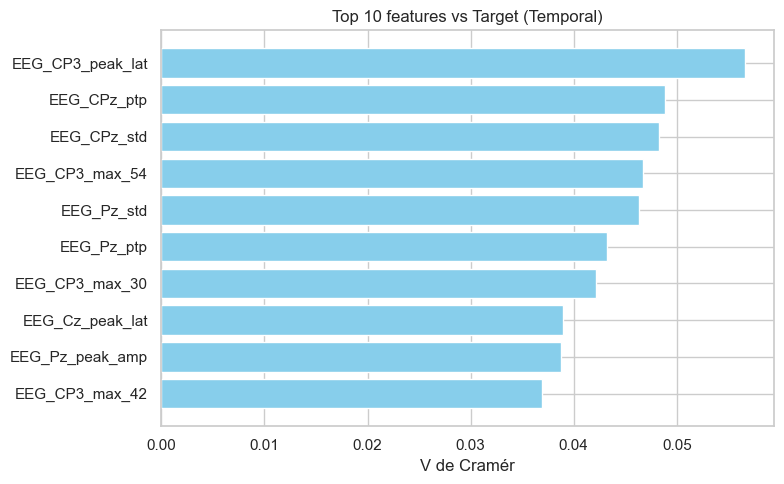


=== PCA 2D de los features ===


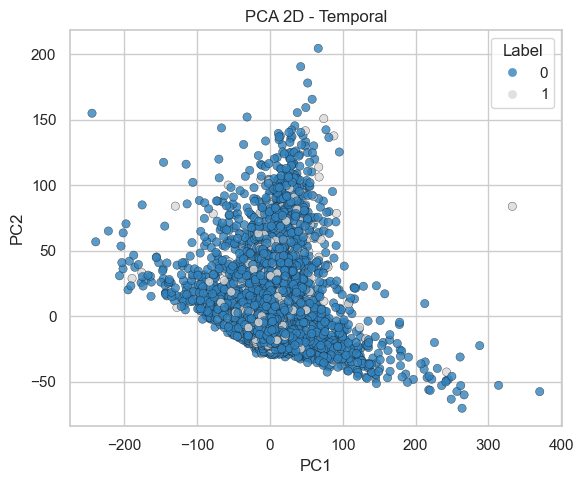


=== Resumen final ===
Total filas: 27850
Total features: 238


In [170]:
analyze_features(df_temp, "Temporal")

Para las features temporales:

* Observamos que la entropía tiene un valor significativamente superior a 0 mientras que el resto de variables son del orden e-n
* No se observaron valores faltantes.
* Observamos un elevado desbalanceo de clases, con predominancia de la clase no objetivo.
* Observamos un elevado número de observaciones atípicas un elevado número de variables. Algunas alcanzando el 10% valores atípicos.
* Observamos alta correlacion entre la energía de los canales 5, 10, 11, 12, 13, 14, superior al 97%.  Por tanto, considerar todas estas variables implica aportar
dependencias y multicolinealidad al modelo.
* La media y la mediana del canal 1 son las variables con mayor impacto sobre la variable objetivo, seguidas de la energía, rms, std del canal 5

In [171]:
plot_average_erp(df_temp)

ERROR: El DataFrame debe tener columnas 'epoch_data' y 'ch_names'.
